# Regresión lineal múltiple: reserva automática y ocupación por ciudad

**Sprint 2 — EDA / Análisis por pregunta de negocio (Operaciones y gestión de inventario)**

**Pregunta de negocio:** ¿Qué repercusión tiene la opción de reserva
automática (`is_instant_bookable`) en la ocupación media de cada ciudad?

Este notebook desarrolla la propuesta descrita en la *Justificación
técnica*: una regresión lineal múltiple que aísla el efecto de la
reserva automática sobre la ocupación, controlando por ciudad, precio,
capacidad, tipo de alojamiento y valoración.

Siguiendo la observación de la mentora Verónica:
- Se habla de **ocupación** (días ocupados) y no de disponibilidad.
- La variable dependiente se expresa en **ocupación en días**, no en
  porcentaje, ya que se va a modelar con regresión lineal.
- Se revisa con cuidado la posible **multicolinealidad** entre
  `bedrooms` (número de habitaciones), `room_type` (tipo de alojamiento)
  y `accommodates` (capacidad), antes de dar por buenos los
  coeficientes del modelo.

El análisis avanza **de lo general a lo particular**: primero una
foto agregada de la ocupación por ciudad y por reserva automática,
después la revisión de colinealidad entre variables explicativas, y
por último el modelo de regresión múltiple con su verificación de
supuestos.

## 1. Librerías

In [62]:
import sys
!{sys.executable} -m pip install statsmodels

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0 -> 26.1.2
[notice] To update, run: C:\Users\lacal\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [63]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import jarque_bera
from statsmodels.tools.tools import add_constant
from patsy import dmatrix
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Carga de datos y preparación de los mísmos

Partimos del dataset ya transformado por el equipo
(`clean_dataset_29_06_2026.csv`), que ya incluye las columnas de
ocupación (`occupancy_30/60/90/365`) y la variable
`is_instant_bookable_numeric` generadas en la fase de Data
Transformation.

**Aviso:** este archivo tiene menos registros que el dataset general
de EDA (transformación de la semana pasada). Se usa aquí porque ya
contiene las columnas necesarias; si Data Cleaning ha entregado una
versión más reciente, actualizar la ruta antes de dar el análisis
por definitivo (ver sección de limitaciones al final).

In [64]:
def encontrar_raiz_proyecto(nombre_carpeta='Equip_34'):
    '''
    Sube desde el directorio actual hasta encontrar la carpeta
    raíz del proyecto.
    '''
    actual = Path.cwd()
    for carpeta in [actual] + list(actual.parents):
        if carpeta.name == nombre_carpeta:
            return carpeta
    raise FileNotFoundError(
        f"No se encontró la carpeta '{nombre_carpeta}' subiendo desde {actual}"
    )

raiz_proyecto = encontrar_raiz_proyecto('Equip_34')
ruta = raiz_proyecto / 'Data' / 'raw_dataset_29_06_2026.csv'

print(f"Ruta resuelta: {ruta}")
df = pd.read_csv(ruta)
print(df.shape)
df.head()

Ruta resuelta: c:\Users\lacal\Desktop\IT_ACADEMY\simulador\ProjecteData\Equip_34\Data\raw_dataset_29_06_2026.csv
(7001, 35)


,apartment_id,name,description,host_id,neighbourhood_name,neighbourhood_district,room_type,accommodates,bathrooms,bedrooms,beds,amenities_list,price,minimum_nights,maximum_nights,has_availability,availability_30,availability_60,availability_90,availability_365,number_of_reviews,first_review_date,last_review_date,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,is_instant_bookable,reviews_per_month,country,city,insert_date
0,11964,A ROOM WITH A VIEW,Private bedroom in our attic apartment. Right ...,45553,Centro,NaN,Private room,2,2.0,1.0,1.0,"TV,Internet,Wifi,Air conditioning,Elevator,Buz...",400.0,3,365,VERDADERO,7,20,40,130,78,02/01/2010,05/09/2017,970.0,100.0,100.0,100.0,100.0,100.0,100.0,FALSO,75.0,spain,malaga,31/07/2018
1,21853,Bright and airy room,We have a quiet and sunny room with a good vie...,83531,C�rmenes,Latina,Private room,1,1.0,1.0,1.0,"TV,Internet,Wifi,Air conditioning,Kitchen,Free...",170.0,4,40,VERDADERO,0,0,0,162,33,10/10/2014,15/07/2018,920.0,90.0,90.0,100.0,100.0,80.0,90.0,FALSO,52.0,spain,madrid,10/01/2020
2,32347,Explore Cultural Sights from a Family-Friendly...,Open French doors and step onto a plant-filled...,139939,San Vicente,Casco Antiguo,Entire home/apt,4,1.0,2.0,2.0,"TV,Internet,Wifi,Air conditioning,Wheelchair a...",990.0,2,120,VERDADERO,26,31,31,270,148,05/01/2011,22/07/2019,980.0,100.0,100.0,100.0,100.0,100.0,100.0,VERDADERO,142.0,spain,sevilla,29/07/2019
3,35379,Double 02 CasanovaRooms Barcelona,Room at a my apartment. Kitchen and 2 bathroom...,152232,l'Antiga Esquerra de l'Eixample,Eixample,Private room,2,2.0,1.0,1.0,"TV,Internet,Wifi,Kitchen,Breakfast,Elevator,Bu...",400.0,2,730,VERDADERO,9,23,49,300,292,13/03/2012,04/01/2020,940.0,100.0,90.0,100.0,100.0,100.0,90.0,VERDADERO,306.0,spain,barcelona,10/01/2020
4,35801,Can Torras Farmhouse Studio Suite,Lay in bed & watch sunlight change the mood of...,153805,Quart,NaN,Private room,5,1.0,2.0,5.0,"Wifi,Pool,Free parking on premises,Breakfast,P...",900.0,1,180,VERDADERO,0,19,49,312,36,08/07/2011,08/08/2018,970.0,100.0,100.0,100.0,100.0,100.0,100.0,FALSO,39.0,spain,girona,19/02/2019


In [65]:
#creamos la variable ocupación
plazos = {'30': 30, '60': 60, '90': 90, '365': 365}

for suf, total in plazos.items():
    df[f'occupancy_{suf}'] = total - df[f'availability_{suf}']
    df[f'occupancy_rate_{suf}'] = (df[f'occupancy_{suf}'] / total * 100).round(2)

#muestra de las nuevas columnas de ocupación
df[[f'occupancy_{suf}' for suf in plazos.keys()] + [f'occupancy_rate_{suf}' for suf in plazos.keys()]].head()

,occupancy_30,occupancy_60,occupancy_90,occupancy_365,occupancy_rate_30,occupancy_rate_60,occupancy_rate_90,occupancy_rate_365
0,23,40,50,235,76.67,66.67,55.56,64.38
1,30,60,90,203,100.00,100.00,100.00,55.62
2,4,29,59,95,13.33,48.33,65.56,26.03
3,21,37,41,65,70.00,61.67,45.56,17.81
4,30,41,41,53,100.00,68.33,45.56,14.52


In [66]:
df['is_instant_bookable_numeric'] = df['is_instant_bookable'].map({'VERDADERO': 1, 'FALSO': 0})

print(df['is_instant_bookable_numeric'].value_counts(dropna=False))
print(df['is_instant_bookable'].value_counts(dropna=False))

df[['is_instant_bookable', 'is_instant_bookable_numeric']].head()

is_instant_bookable_numeric
1    3740
0    3261
Name: count, dtype: int64
is_instant_bookable
VERDADERO    3740
FALSO        3261
Name: count, dtype: int64


,is_instant_bookable,is_instant_bookable_numeric
0,FALSO,0
1,FALSO,0
2,VERDADERO,1
3,VERDADERO,1
4,FALSO,0


## 3. Selección de variables para el análisis

Variable dependiente y explicativas según la justificación técnica:

| Rol | Variable | Descripción |
|---|---|---|
| Dependiente | `occupancy_365` | Días ocupados en un año (0-365) |
| Interés | `is_instant_bookable_numeric` | Reserva automática (1 = sí, 0 = no) |
| Control | `city` | Ciudad (8 categorías) |
| Control | `price_€` | Precio por noche |
| Control | `accommodates` | Número máximo de huéspedes que puede alojar el alojamiento. |
| Control | `bedrooms` | Número de habitaciones |
| Control | `room_type` | Tipo de alojamiento (4 categorías) |
| Control | `review_scores_rating` | Valoración |

Se trabaja sobre una copia reducida a estas columnas, y se eliminan
los registros con nulos en cualquiera de ellas (el modelo de
regresión no admite nulos).

In [67]:
df['is_instant_bookable_numeric'] = df['is_instant_bookable'].map({'VERDADERO': 1, 'FALSO': 0})

print(df['is_instant_bookable_numeric'].value_counts(dropna=False))
print(df['is_instant_bookable'].value_counts(dropna=False))

df[['is_instant_bookable', 'is_instant_bookable_numeric']].head()

is_instant_bookable_numeric
1    3740
0    3261
Name: count, dtype: int64
is_instant_bookable
VERDADERO    3740
FALSO        3261
Name: count, dtype: int64


,is_instant_bookable,is_instant_bookable_numeric
0,FALSO,0
1,FALSO,0
2,VERDADERO,1
3,VERDADERO,1
4,FALSO,0


In [68]:
for col in df.columns:
    print(col)

apartment_id
name
description
host_id
neighbourhood_name
neighbourhood_district
room_type
accommodates
bathrooms
bedrooms
beds
amenities_list
price
minimum_nights
maximum_nights
has_availability
availability_30
availability_60
availability_90
availability_365
number_of_reviews
first_review_date
last_review_date
review_scores_rating
review_scores_accuracy
review_scores_cleanliness
review_scores_checkin
review_scores_communication
review_scores_location
review_scores_value
is_instant_bookable
reviews_per_month
country
city
insert_date
occupancy_30
occupancy_rate_30
occupancy_60
occupancy_rate_60
occupancy_90
occupancy_rate_90
occupancy_365
occupancy_rate_365
is_instant_bookable_numeric


In [69]:
columnas_modelo = [
    'occupancy_365', 'occupancy_90', 'occupancy_60', 'occupancy_30',
    'is_instant_bookable_numeric', 'city', 'price', 'accommodates',
    'bedrooms', 'room_type', 'review_scores_rating'
]

df_modelo = df[columnas_modelo].copy()

print("Registros antes de eliminar nulos:", df_modelo.shape[0])
nulos = df_modelo.isna().sum()
print(nulos[nulos > 0])

df_modelo = df_modelo.dropna()
print("Registros tras eliminar nulos:", df_modelo.shape[0])

Registros antes de eliminar nulos: 7001
price                    131
bedrooms                  29
review_scores_rating    1327
dtype: int64
Registros tras eliminar nulos: 5568


| Rol         | Variable             |
| ----------- | -------------------- |
| Dependiente | occupancy_365        |
| Interés     | is_instant_bookable  |
| Control     | city                 |
| Control     | room_type            |
| Control     | price                |
| Control     | accommodates         |
| Control     | bedrooms             |
| Control     | review_scores_rating |


# 4. Análisis exploratorio

In [70]:
# ESTADÍSTICOS DESCRIPTIVOS
# Resumen de las variables numéricas utilizadas en el modelo
df_modelo[
    [
        "occupancy_365",
        "price",
        "accommodates",
        "bedrooms",
        "review_scores_rating"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
occupancy_365,5568.0,173.802802,128.208554,0.0,49.0,165.5,293.0,365.0
price,5568.0,955.945402,800.473362,80.0,450.0,700.0,1170.0,6071.0
accommodates,5568.0,4.195941,2.433496,1.0,2.0,4.0,6.0,16.0
bedrooms,5568.0,1.873922,1.175577,0.0,1.0,2.0,3.0,9.0
review_scores_rating,5568.0,920.053879,85.422464,200.0,890.0,940.0,980.0,1000.0


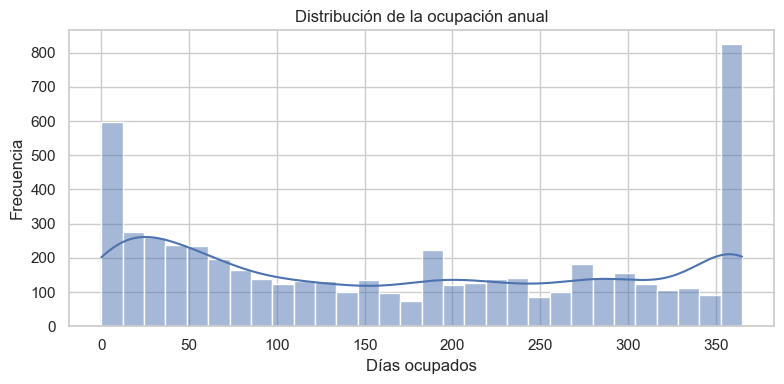

In [71]:
# DISTRIBUCIÓN DE LA VARIABLE DEPENDIENTE


plt.figure(figsize=(8,4))

sns.histplot(
    data=df_modelo,
    x="occupancy_365",
    bins=30,
    kde=True
)

plt.title("Distribución de la ocupación anual")
plt.xlabel("Días ocupados")
plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

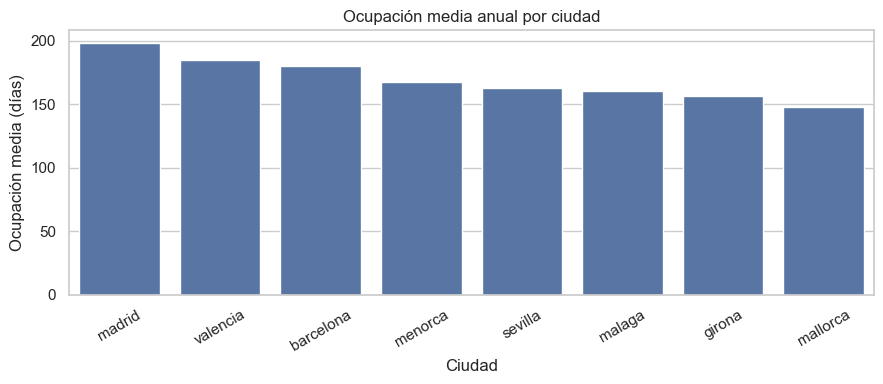

In [72]:
# OCUPACIÓN MEDIA POR CIUDAD

ocupacion_ciudad = (
    df_modelo
    .groupby("city")["occupancy_365"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9,4))

sns.barplot(
    x=ocupacion_ciudad.index,
    y=ocupacion_ciudad.values
)

plt.title("Ocupación media anual por ciudad")
plt.xlabel("Ciudad")
plt.ylabel("Ocupación media (días)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

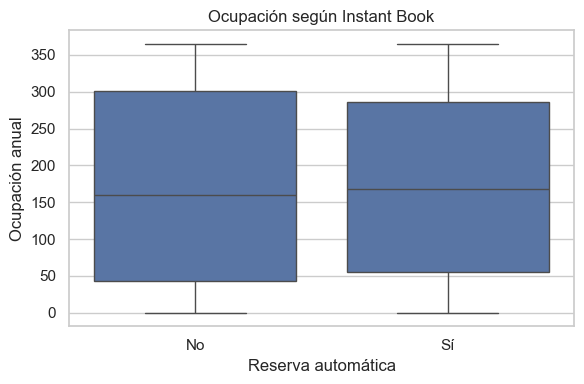

In [73]:
# OCUPACIÓN SEGÚN RESERVA AUTOMÁTICA

plt.figure(figsize=(6,4))

sns.boxplot(
    data=df_modelo,
    x="is_instant_bookable_numeric",
    y="occupancy_365"
)

plt.xticks([0,1],["No","Sí"])

plt.xlabel("Reserva automática")
plt.ylabel("Ocupación anual")

plt.title("Ocupación según Instant Book")

plt.tight_layout()
plt.show()

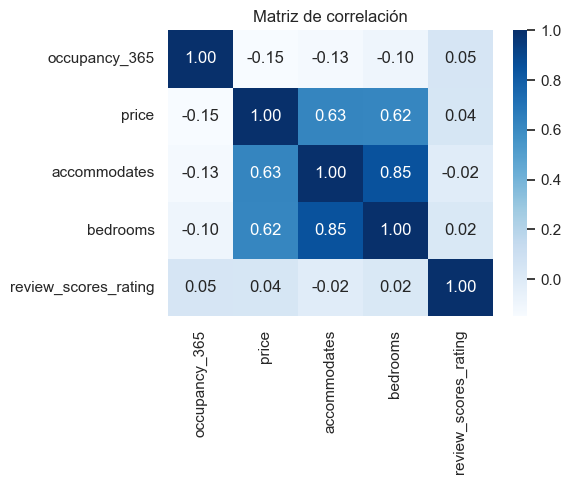

In [74]:
# MATRIZ DE CORRELACIÓN

variables_corr = [
    "occupancy_365",
    "price",
    "accommodates",
    "bedrooms",
    "review_scores_rating"
]

corr = df_modelo[variables_corr].corr()

plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Matriz de correlación")

plt.tight_layout()
plt.show()

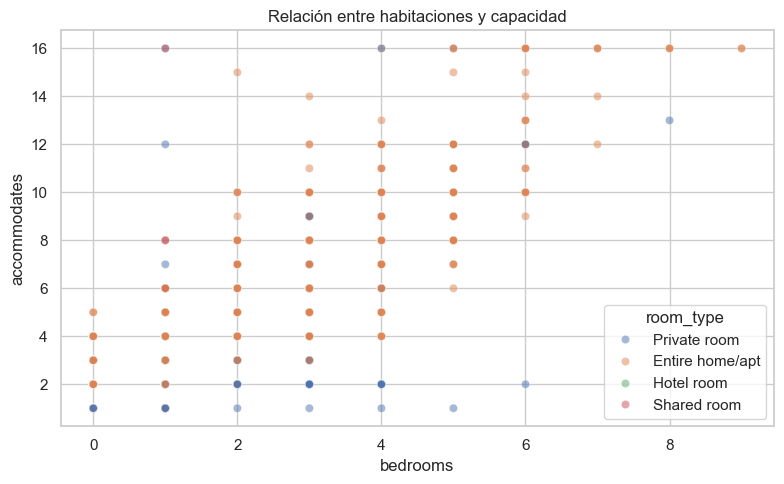

In [75]:
# RELACIÓN ENTRE BEDROOMS Y ACCOMMODATES

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df_modelo,
    x="bedrooms",
    y="accommodates",
    hue="room_type",
    alpha=0.5
)

plt.title("Relación entre habitaciones y capacidad")

plt.tight_layout()
plt.show()

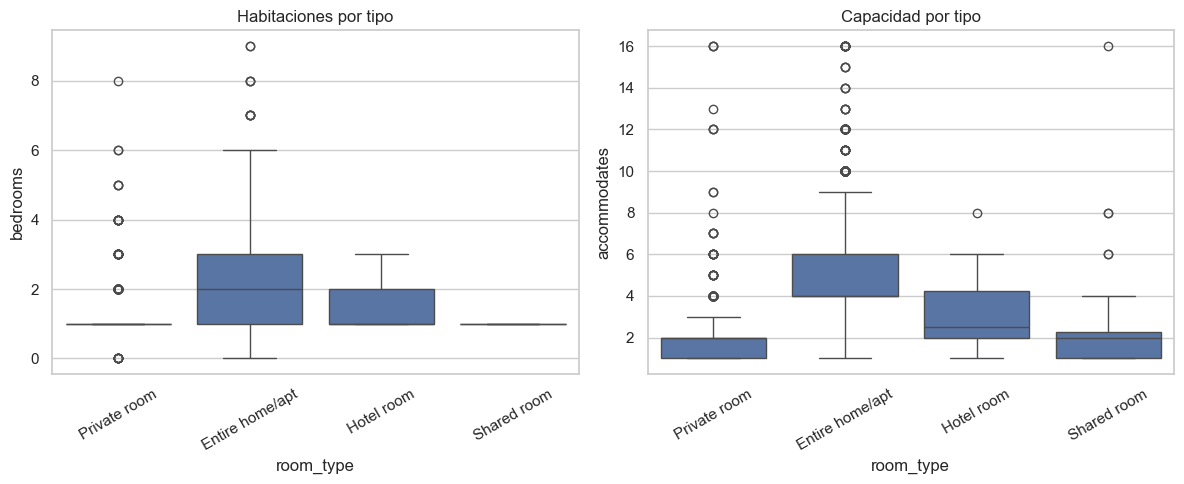

In [76]:
# ROOM TYPE

fig, axes = plt.subplots(1,2,figsize=(12,5))

sns.boxplot(
    data=df_modelo,
    x="room_type",
    y="bedrooms",
    ax=axes[0]
)

axes[0].set_title("Habitaciones por tipo")
axes[0].tick_params(axis="x",rotation=30)

sns.boxplot(
    data=df_modelo,
    x="room_type",
    y="accommodates",
    ax=axes[1]
)

axes[1].set_title("Capacidad por tipo")
axes[1].tick_params(axis="x",rotation=30)

plt.tight_layout()

plt.show()

C:\Users\lacal\AppData\Local\Temp\ipykernel_90776\2367616773.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


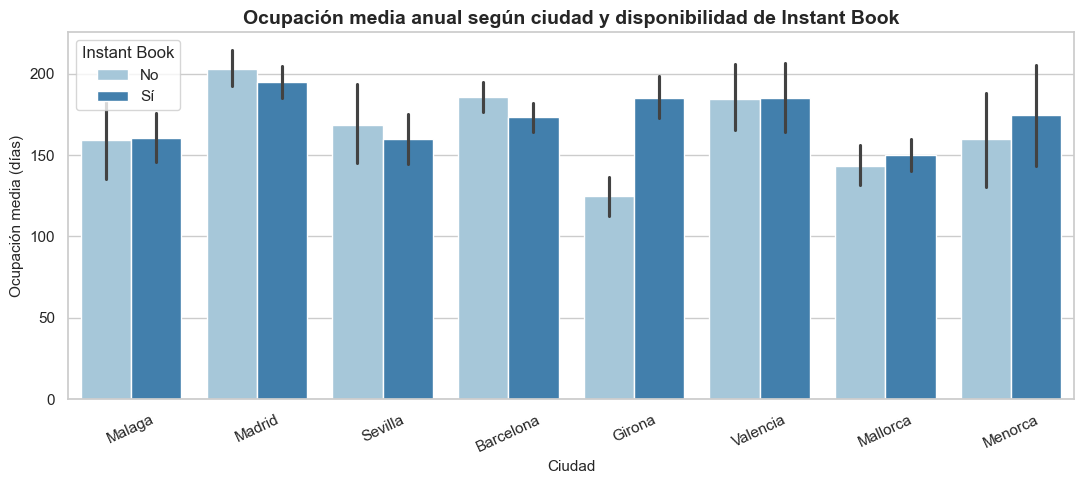

In [77]:
# OCUPACIÓN MEDIA POR CIUDAD SEGÚN INSTANT BOOK

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

# Crear figura
fig, ax = plt.subplots(figsize=(11, 5))

# Gráfico
sns.barplot(
    data=df_modelo,
    x="city",
    y="occupancy_365",
    hue="is_instant_bookable_numeric",
    estimator="mean",
    errorbar=("ci", 95),
    palette=["#9ecae1", "#3182bd"],   # azul claro y azul oscuro
    ax=ax
)

# Cambiar etiquetas de la leyenda
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles,
    ["No", "Sí"],
    title="Instant Book",
    frameon=True,
    loc="upper left"
)

# Poner las ciudades con mayúscula
ax.set_xticklabels(
    [c.title() for c in df_modelo["city"].unique()],
    rotation=25
)

# Títulos
ax.set_title(
    "Ocupación media anual según ciudad y disponibilidad de Instant Book",
    fontsize=14,
    weight="bold"
)

ax.set_xlabel("Ciudad", fontsize=11)
ax.set_ylabel("Ocupación media (días)", fontsize=11)

plt.tight_layout()
plt.show()

## 5. Revisión de multicolinealidad

Verónica ha señalado que puede existir multicolinealidad entre:
`bedrooms` (número de habitaciones), `room_type` (tipo de alojamiento)
y `accommodates` (capacidad), ya que conceptualmente están muy
relacionadas (un alojamiento con más habitaciones suele tener más
capacidad y suele ser "Entire home/apt").

Se revisa esto **antes** de meter estas variables en el modelo.

Correlación bedrooms vs accommodates: 0.85


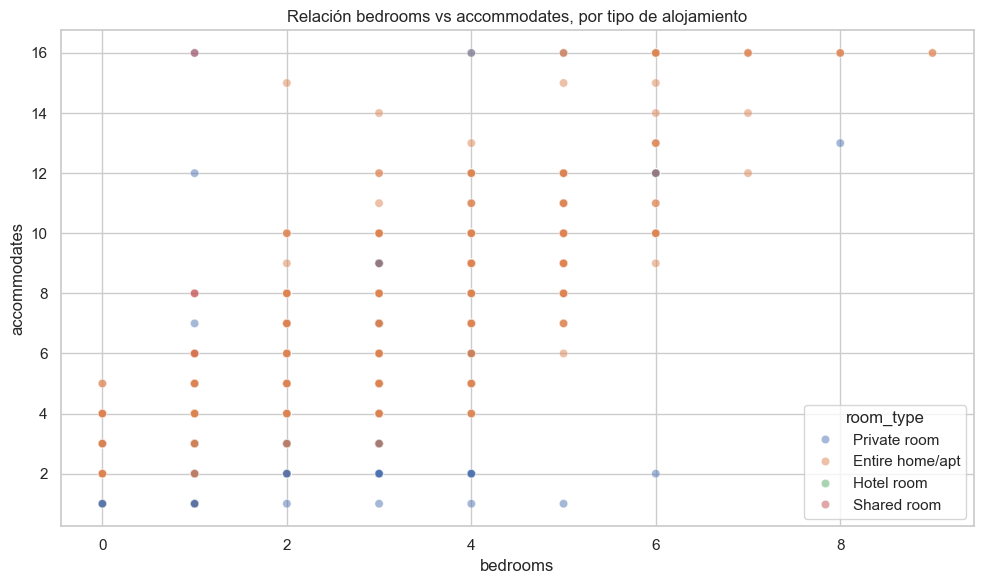

In [78]:
# Correlación numérica directa entre bedrooms y accommodates
corr_bed_acc = df_modelo[['bedrooms', 'accommodates']].corr().iloc[0, 1]
print(f"Correlación bedrooms vs accommodates: {corr_bed_acc:.2f}")

fig, ax = plt.subplots()
sns.scatterplot(data=df_modelo, x='bedrooms', y='accommodates',
                 hue='room_type', alpha=0.5, ax=ax)
ax.set_title('Relación bedrooms vs accommodates, por tipo de alojamiento')
plt.tight_layout()
plt.show()

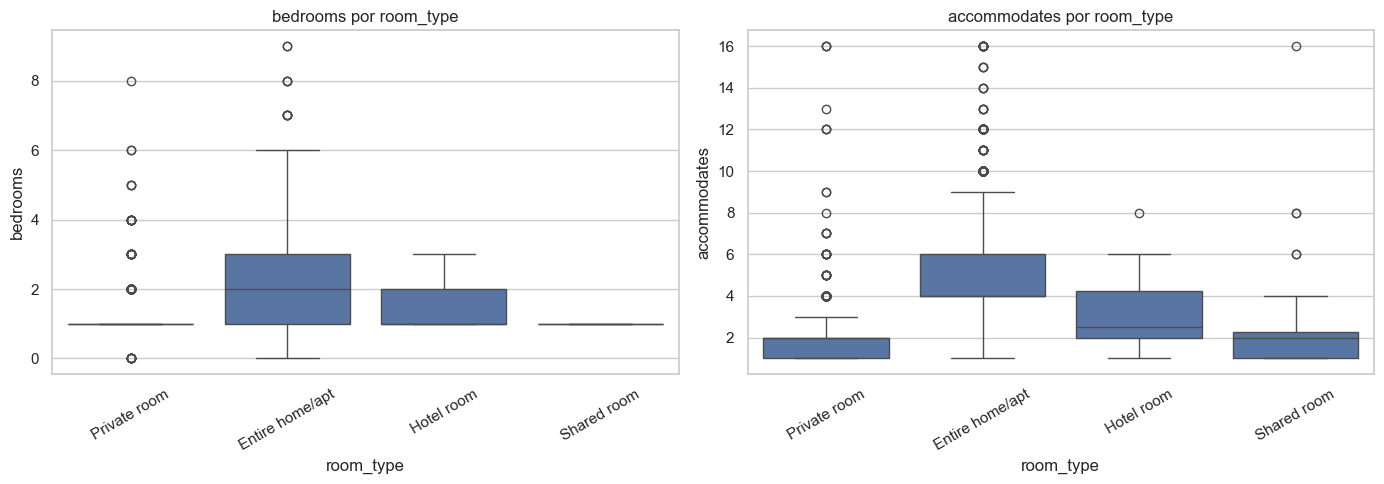

In [79]:
# Relación entre room_type y las otras dos variables (vía boxplots)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df_modelo, x='room_type', y='bedrooms', ax=axes[0])
axes[0].set_title('bedrooms por room_type')
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=df_modelo, x='room_type', y='accommodates', ax=axes[1])
axes[1].set_title('accommodates por room_type')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## 7. Comprobación de la multicolinealidad (VIF)

Antes de ajustar la regresión lineal múltiple, se evalúa la posible existencia de multicolinealidad entre las variables explicativas mediante el Variance Inflation Factor (VIF). Se construye la misma matriz de diseño que utilizará posteriormente el modelo de regresión. Si alguna variable presenta un VIF superior a 5, se consideraría eliminarla del modelo.

In [80]:
# COMPROBACIÓN DE LA MULTICOLINEALIDAD

# Construimos la misma matriz de diseño que utilizará la regresión.
# Las variables categóricas se codifican automáticamente en variables dummy.

X = dmatrix(
    """
    C(is_instant_bookable_numeric) +
    C(city) +
    C(room_type) +
    price +
    accommodates +
    bedrooms +
    review_scores_rating
    """,
    data=df_modelo,
    return_type="dataframe"
)

# Calculamos el VIF de cada variable explicativa
vif = pd.DataFrame({
    "Variable": X.columns,
    "VIF": [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]
})

vif = vif[vif["Variable"] != "Intercept"]
vif = vif.sort_values("VIF", ascending=False)


vif

,Variable,VIF
13,accommodates,4.755365
14,bedrooms,4.221611
12,price,1.849431
10,C(room_type)[T.Private room],1.714515
5,C(city)[T.mallorca],1.495961
2,C(city)[T.girona],1.438351
3,C(city)[T.madrid],1.419198
4,C(city)[T.malaga],1.184409
7,C(city)[T.sevilla],1.176927
8,C(city)[T.valencia],1.156260


Los valores del VIF fueron inferiores al umbral habitual de 5 para todas las variables explicativas. Las variables accommodates (4,76) y bedrooms (4,22) presentan los valores más elevados, lo que confirma que existe cierta relación entre ambas. No obstante, ninguno de los valores supera el umbral considerado problemático, por lo que se concluye que no existe una multicolinealidad relevante y se mantienen todas las variables en el modelo.

## 8. Modelo final y resultados

Las variables categóricas (city, room_type e is_instant_bookable_numeric) se incorporan al modelo mediante C(). La API de fórmulas de statsmodels realiza automáticamente la codificación en variables dummy y selecciona una categoría de referencia para cada variable.

In [81]:
modelo = smf.ols(
    """
    occupancy_365 ~
    C(is_instant_bookable_numeric) +
    C(city) +
    C(room_type) +
    price +
    accommodates +
    bedrooms +
    review_scores_rating
    """,
    data=df_modelo
).fit()
modelo.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          occupancy_365   R-squared:                       0.043
Model:                            OLS   Adj. R-squared:                  0.040
Method:                 Least Squares   F-statistic:                     16.54
Date:                Thu, 09 Jul 2026   Prob (F-statistic):           3.40e-43
Time:                        10:43:30   Log-Likelihood:                -34804.
No. Observations:                5568   AIC:                         6.964e+04
Df Residuals:                    5552   BIC:                         6.975e+04
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
=======================================================================================================
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                             110.0905     19.266      5.714      0.000      72.323     147.858
C(is_instant_bookable_numeric)[T.1]     8.6609      3.451      2.509      0.012       1.895      15.427
C(city)[T.girona]                     -10.7473      5.867     -1.832      0.067     -22.250       0.755
C(city)[T.madrid]                      19.8601      4.842      4.101      0.000      10.367      29.353
C(city)[T.malaga]                     -16.1692      7.906     -2.045      0.041     -31.668      -0.670
C(city)[T.mallorca]                   -18.9231      5.897     -3.209      0.001     -30.484      -7.362
C(city)[T.menorca]                      1.3852     12.369      0.112      0.911     -22.863      25.633
C(city)[T.sevilla]                    -12.1008      7.734     -1.565      0.118     -27.262       3.061
C(city)[T.valencia]                     7.2067      8.227      0.876      0.381      -8.922      23.335
C(room_type)[T.Hotel room]             26.3999     22.427      1.177      0.239     -17.565      70.365
C(room_type)[T.Private room]           17.7026      4.891      3.619      0.000       8.114      27.291
C(room_type)[T.Shared room]           -40.1963     22.448     -1.791      0.073     -84.203       3.810
price                                  -0.0179      0.003     -6.263      0.000      -0.024      -0.012
accommodates                           -4.1989      1.509     -2.783      0.005      -7.156      -1.242
bedrooms                               10.4168      2.942      3.540      0.000       4.649      16.185
review_scores_rating                    0.0765      0.020      3.817      0.000       0.037       0.116
==============================================================================
Omnibus:                    21484.579   Durbin-Watson:                   1.887
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              404.459
Skew:                           0.101   Prob(JB):                     1.49e-88
Kurtosis:                       1.695   Cond. No.                     1.97e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.97e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

El modelo de regresión lineal múltiple resultó significativo (p < 0,001),  indica que el conjunto de variables incluidas aporta información para explicar la ocupación anual de los alojamientos. Aunque el poder explicativo del modelo es limitado (R² ajustado = 0,040), los resultados muestran que la reserva automática (Instant Book) tiene un efecto positivo y estadísticamente significativo sobre la ocupación. En concreto, los alojamientos con reserva automática presentan, en promedio, 8,7 días más de ocupación al año que aquellos que requieren aprobación del propietario, manteniendo constantes la ciudad, el tipo de alojamiento, el precio, la capacidad, el número de habitaciones y la valoración. además, variables como el número de habitaciones y la valoración muestran una asociación positiva con la ocupación, mientras que el precio y la capacidad presentan una asociación negativa.

Aunque el resumen del modelo muestra un número de condición elevado, el análisis mediante VIF no detectó problemas importantes de multicolinealidad entre las variables explicativas incluidas.

## 9. Verificación de supuestos pendientes

Según la justificación técnica, quedaban dos supuestos por
verificar: **normalidad de los residuos** y **multicolinealidad**
(ya resuelta en la sección 7 con el VIF). Se añade también una
revisión visual de homocedasticidad.

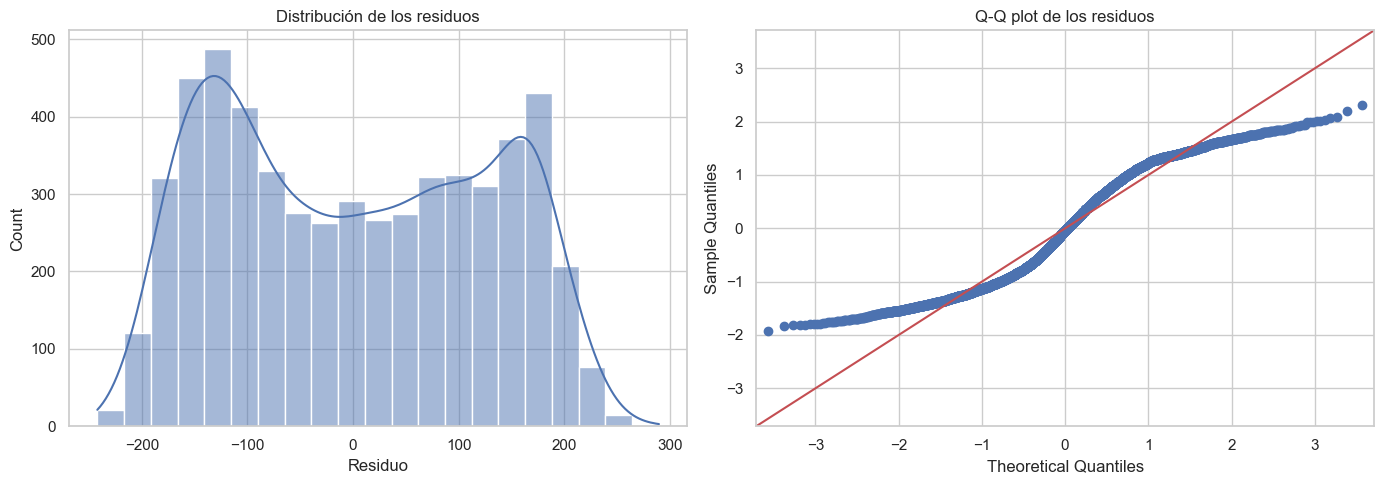

In [83]:
residuos = modelo.resid
valores_ajustados = modelo.fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(residuos, kde=True, ax=axes[0])
axes[0].set_title('Distribución de los residuos')
axes[0].set_xlabel('Residuo')

sm.qqplot(residuos, line='45', fit=True, ax=axes[1])
axes[1].set_title('Q-Q plot de los residuos')

plt.tight_layout()
plt.savefig('../Results/residuos_modelo_ocupacion.png', dpi=150,
            bbox_inches='tight')
plt.show()

In [84]:
# Test de Jarque-Bera para normalidad de los residuos
jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(residuos)
print(f"Jarque-Bera: estadístico={jb_stat:.2f}, p-valor={jb_pvalue:.4f}")
print("H0: los residuos siguen una distribución normal.")
print("Si p-valor < 0.05, se rechaza la normalidad de los residuos.")

Jarque-Bera: estadístico=404.46, p-valor=0.0000
H0: los residuos siguen una distribución normal.
Si p-valor < 0.05, se rechaza la normalidad de los residuos.


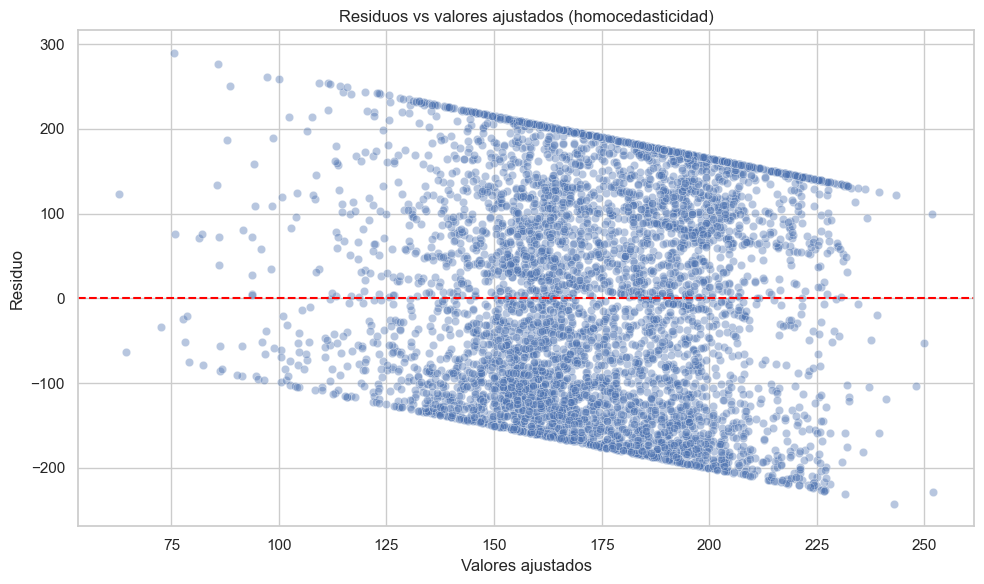

In [85]:
# Homocedasticidad: residuos vs valores ajustados
fig, ax = plt.subplots()
sns.scatterplot(x=valores_ajustados, y=residuos, alpha=0.4, ax=ax)
ax.axhline(0, color='red', linestyle='--')
ax.set_title('Residuos vs valores ajustados (homocedasticidad)')
ax.set_xlabel('Valores ajustados')
ax.set_ylabel('Residuo')
plt.tight_layout()
plt.show()

**Cómo interpretar esta sección:** una nube de puntos sin forma
de embudo alrededor del cero indica homocedasticidad razonable; un
histograma de residuos con forma de campana y puntos alineados en el
Q-Q plot apoyan la normalidad. Si estos supuestos no se cumplen bien,
los p-valores del modelo deben interpretarse con cautela (no invalidan
el modelo, pero piden prudencia en las conclusiones).

## 10. Robustez: repetir el modelo a 30, 60 y 90 días

La justificación técnica propone repetir el análisis para otros
horizontes de disponibilidad/ocupación, para ver si el efecto de la
reserva automática es estable o cambia según el plazo.

In [ ]:
import statsmodels.formula.api as smf

# Variables dependientes que queremos comparar
horizontes = [
    "occupancy_30",
    "occupancy_60",
    "occupancy_90",
    "occupancy_365"]

resultados = []

for y in horizontes:

    formula = f"""
    {y} ~
    C(is_instant_bookable_numeric) +
    C(city) +
    C(room_type) +
    price +
    accommodates +
    bedrooms +
    review_scores_rating
    """

    modelo = smf.ols(
        formula=formula,
        data=df_modelo).fit()

    resultados.append({
        "Horizonte": y,
        "Coeficiente Instant Book": round(
            modelo.params["C(is_instant_bookable_numeric)[T.1]"], 2
        ),
        "p-valor": round(
            modelo.pvalues["C(is_instant_bookable_numeric)[T.1]"], 4
        ),
        "R² ajustado": round(
            modelo.rsquared_adj, 3
        )})

resultados_robustez = pd.DataFrame(resultados)

resultados_robustez

,Horizonte,Coeficiente Instant Book,p-valor,R² ajustado
0,occupancy_30,0.56,0.0686,0.032
1,occupancy_60,0.53,0.3760,0.025
2,occupancy_90,0.54,0.5386,0.021
3,occupancy_365,8.66,0.0121,0.040


Esta tabla permite comparar, de un vistazo, si el efecto de la
reserva automática (coeficiente, significancia y R² ajustado) se
mantiene estable entre los distintos horizontes temporales o si
varía de forma relevante.

## 11. Conclusiones y propuestas

*(Completar tras ejecutar el notebook con los datos reales; guía de
qué debe contener cada punto)*

**Conclusiones a partir del modelo:**
- Indicar el signo, la magnitud y la significancia del coeficiente
  de `is_instant_bookable_numeric` en el modelo de 365 días.
- Indicar si el efecto es estable o varía entre 30/60/90/365 días
  (sección 10).
- Indicar si los supuestos de normalidad y homocedasticidad se
  cumplen razonablemente (sección 9), y matizar la confianza en los
  resultados si no es así.
- Recordar el alcance real del modelo: muestra **correlación
  controlada**, no causalidad, y depende de las variables incluidas.

**Propuestas de negocio (a ajustar según el signo del coeficiente):**
- Si el efecto es positivo y significativo: valorar incentivar o
  comunicar activamente la opción de reserva automática a los
  anfitriones de las ciudades con menor ocupación media (ver tabla
  de la sección 4), como palanca operativa de bajo coste.
- Si el efecto es pequeño o no significativo: no basar la estrategia
  de ocupación únicamente en la reserva automática; explorar otras
  variables de control (precio, valoración) que puedan tener un peso
  mayor según los coeficientes del modelo.
- En cualquier caso, comunicar el resultado como una asociación
  controlada por otros factores, no como una relación de causa-efecto,
  para evitar decisiones operativas basadas en una lectura
  simplificada del dato.

**Limitaciones y próximos pasos (heredados de la justificación
técnica):**
- El dataset usado aquí (`clean_dataset_29_06_2026.csv`, 6733 registros) es una versión previa a la actual del proyecto; conviene repetir el análisis con la versión de datos más reciente una vez confirmada por la mentora.
- No se incluyen variables como el tipo de anfitrión, que podrían
  explicar parte de la ocupación y no están en este modelo.
- Se recomienda validar los resultados con el resto del equipo antes
  de trasladarlos a Power BI o a la documentación final.